In [2]:
import datetime
import torch
import torch.nn as nn
import libs
from libs.data_gene import *
from libs.config import * 
from libs.module import LatentModel, Decoder
from libs.train_module import trainer
from libs.evaluate_module import *


In [3]:

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#sol_name = f"./data/solution_{config['eq_name']}.h5"

print(f"Using device : {device}")
print(f"Loading data : {config['sol_name']}")

# ── data ─────────────────────────────────────────────────
x_ref, train_loader, test_loader = get_dataloaders(
    config["sol_name"], batch_size=config["batch_size"]
)

for params_batch, phi_batch in train_loader:
    print("train params :", params_batch.shape)   # (B, 2)
    print("train phi    :", phi_batch.shape)       # (B, N)
    break

# ── models ───────────────────────────────────────────────
model1 = LatentModel(
    input_dim          = config["input_dim"],
    hidden_dims        = config["hidden_dims"],
    latent_feature_dim = config["latent_feature_dim"],
    n_latent           = config["n_latent"],
    activation         = config["activation"],
    output_activation  = config["output_activation"],
).to(device)

model2 = Decoder(
    latent_dim       = config["latent_feature_dim"],
    hidden_conv_dims = config["hidden_conv_dims"],
    output_sol_dim   = config["output_sol_dim"],
).to(device)

models = nn.ModuleList([model1, model2])

params_all, phi_pred, phi_true, rel_errors = evaluate_model(models, test_loader, device, config["model_save_path"], config["error_save_path"])


Using device : cpu
Loading data : ./data/solution_Ex1.h5
train params : torch.Size([32, 2])
train phi    : torch.Size([32, 4096])
Sequential(
  (0): ConvTranspose1d(16, 256, kernel_size=(4,), stride=(2,), padding=(1,))
  (1): ReLU()
  (2): ConvTranspose1d(256, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (3): ReLU()
  (4): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (5): ReLU()
  (6): ConvTranspose1d(64, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (7): ReLU()
  (8): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (9): ReLU()
  (10): ConvTranspose1d(32, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (11): ReLU()
  (12): Conv1d(32, 1, kernel_size=(1,), stride=(1,))
)
The relative L2 error for each parameter is stored
Test MSE loss         : 0.000003
Mean relative L2 error: 0.0136 ± 0.0061


In [4]:
def plot_results_witherror(x, params, phi_pred, phi_true,
                           indices=None, save_path=None):
    if indices is None:
        M = phi_pred.shape[0]
        indices = [0, M // 3, 2 * M // 3, M - 1]
        print(indices)

    plt.rcParams.update({
        "font.family":    "serif",
        "font.size":       11,
        "axes.labelsize":  12,
        "axes.titlesize":  11,
        "legend.fontsize":  9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth":   0.8,
        "lines.linewidth":  1.8,
    })

    colors = ["#2166ac", "#d6604d", "#4dac26", "#7b3294"]

    fig = plt.figure(figsize=(11, 11))

    # 5 rows: [main, error, SPACER, main, error]
    # height_ratios controls the relative height of each row
    gs = fig.add_gridspec(
        nrows=5, ncols=2,
        height_ratios=[3, 1, 0.5, 3, 1],  # spacer row (index 2) separates pairs
        hspace=0.08,                        # tight within each pair
        wspace=0.35,
    )

    # (col, main_row) — error panel is always main_row + 1
    layout = [(0, 0), (1, 0), (0, 3), (1, 3)]

    # ── pre-compute global error max for shared y-axis ────────
    global_max = max(
        np.abs(phi_pred[idx] ** 2 - phi_true[idx] ** 2).max()
        for idx in indices
    )

    ax_err_ref = None  # for sharey across all error panels

    for i, (idx, color) in enumerate(zip(indices, colors)):
        col, main_row = layout[i]

        ax_main = fig.add_subplot(gs[main_row,     col])
        ax_err  = fig.add_subplot(gs[main_row + 1, col],
                                  sharex=ax_main,
                                  sharey=ax_err_ref)   # unified y-axis

        if ax_err_ref is None:
            ax_err_ref = ax_err

        mu    = params[idx, 0]
        delta = params[idx, 1]

        pred_sq = phi_pred[idx] ** 2
        true_sq = phi_true[idx] ** 2
        abs_err = np.abs(pred_sq - true_sq)

        # ── main panel ───────────────────────────────────────
        ax_main.plot(x, true_sq, color=color,
                     linestyle="-",  label="Analytical", linewidth=1.8)
        ax_main.plot(x, pred_sq, color="k",
                     linestyle="--", label="Surrogate",  linewidth=1.4, alpha=0.85)
        ax_main.set_title(rf"$\mu={mu:.4f},\ \delta={delta:.3f}$", pad=5)
        ax_main.set_xlim(x[0], x[-1])
        ax_main.set_ylim(bottom=0)
        ax_main.set_ylabel(r"$|\Psi|^2$")
        ax_main.legend(frameon=False)
        ax_main.tick_params(labelbottom=False)

        # ── error panel ──────────────────────────────────────
        ax_err.fill_between(x, abs_err, alpha=0.25, color=color)
        ax_err.plot(x, abs_err, color=color, linewidth=1.2)
        ax_err.set_xlim(x[0], x[-1])
        ax_err.set_ylim(0, global_max * 1.1)
        ax_err.set_xlabel(r"$x$")
        ax_err.set_ylabel(r"$|\mathrm{err}|$", fontsize=10)
        ax_err.tick_params(labelsize=9)
        ax_err.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:.1e}")
        )

    fig.suptitle(
        r"Surrogate vs Analytical Droplet Solution $|\phi_{D2}|^2$",
        fontsize=13, y=1.01
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved → {save_path}")

    plt.show()

In [5]:
phi_pred.shape 

(120, 4096)

array([-2.00000000e+01, -1.99902320e+01, -1.99804640e+01, ...,
       -1.46520147e-02, -4.88400488e-03,  4.88400488e-03])

In [ ]:
phi_pred

[0, 40, 80, 119]


<ipython-input-4-bbb63b702d89>:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved → ./result/Ex1_witherror_sampled_plot.png


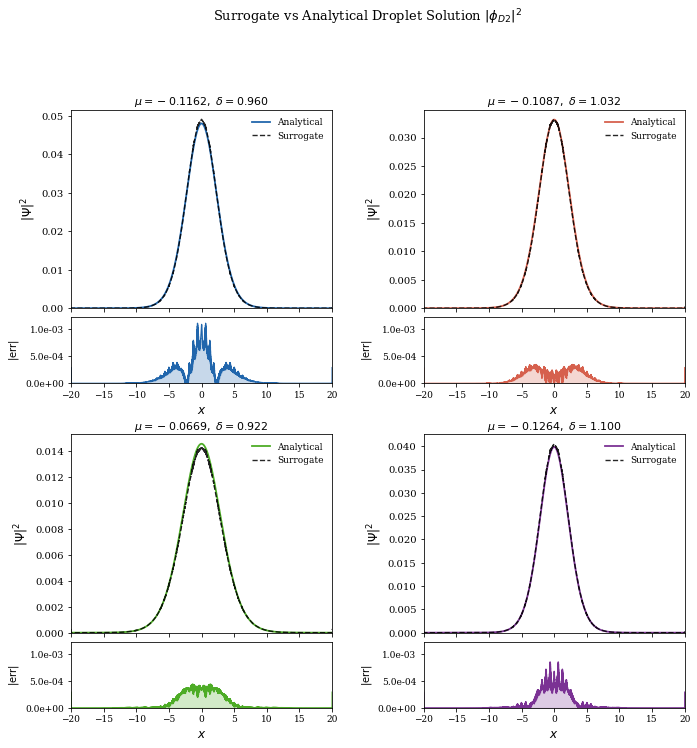

In [5]:

#params = np.concatenate([test_data['mu'][:, None], test_data['delta'][:, None]], axis = 1) 

plot_results_witherror(x_ref, params_all, phi_pred, phi_true,
            indices=None, save_path=config["save_path_witherror"]) 

 